In [ ]:
import pandas as pd
import numpy as np

In [ ]:
np.random.seed(23)

In [ ]:
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,1],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

/tmp/ipykernel_12003/3257188729.py:10: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)


In [ ]:
df.head()

,feature1,feature2,feature3,target
11,-0.939020,-0.480856,0.821010,1
23,2.006987,0.438976,1.286056,0
32,2.312095,1.594934,2.708881,0
6,1.260098,1.415124,-2.143375,1
7,0.512206,-0.202883,0.213886,1


In [ ]:
import plotly.express as px

fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
                    color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [ ]:
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])
print('covariance matrix:\n', covariance_matrix)

covariance matrix:
 [[1.02564103 0.42543945 0.16647754]
 [0.42543945 1.02564103 0.38563185]
 [0.16647754 0.38563185 1.02564103]]


In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [ ]:
eigen_values

array([1.68881201, 0.86012362, 0.52798744])

In [ ]:
eigen_vectors

array([[-0.5500854 , -0.66390383,  0.50659428],
       [-0.65450409, -0.03403136, -0.75529217],
       [-0.51868145,  0.74704322,  0.41580762]])

Populating the interactive namespace from numpy and matplotlib


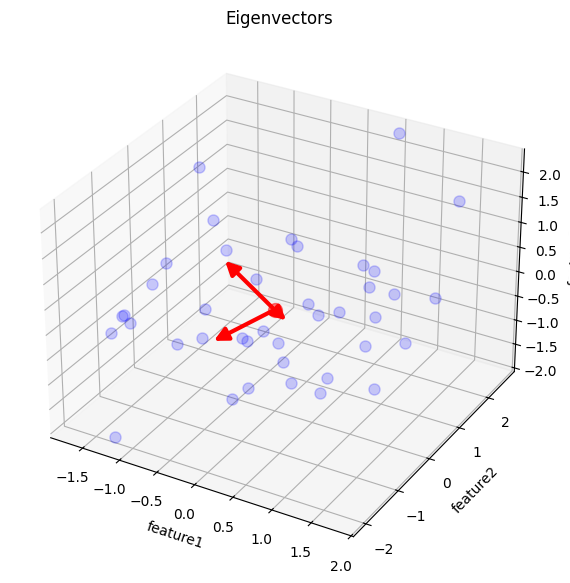

In [ ]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )
        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )
        FancyArrowPatch.draw(self, renderer)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)

mean = df[['feature1', 'feature2', 'feature3']].mean()

ax.plot(
    [mean['feature1']],
    [mean['feature2']],
    [mean['feature3']],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)

for v in eigen_vectors.T:
    a = Arrow3D(
        [mean['feature1'], mean['feature1'] + v[0]],
        [mean['feature2'], mean['feature2'] + v[1]],
        [mean['feature3'], mean['feature3'] + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('Eigenvectors')
plt.show()

In [ ]:
pc = eigen_vectors[0:2]
pc

array([[-0.5500854 , -0.66390383,  0.50659428],
       [-0.65450409, -0.03403136, -0.75529217]])

In [ ]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.548140,0.430329,1
1,-0.433386,-1.670408,0
2,-0.850885,-2.805956,0
3,-2.260621,0.927953,1
4,0.346402,-0.064285,1


In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()